<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_006_reduccion_de_dimensiones/011_UMAP_Explicaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UMAP: Uniform Manifold Approximation and Projection

UMAP es un algoritmo de reducción de dimensionalidad no supervisado. Se utiliza para representar datos complejos en un espacio de menor dimensión (2D o 3D), preservando tanto la estructura local como global de los datos.

Es útil para:

- Visualización de datos
- Preprocesamiento para clustering
- Exploración de datos de alta dimensión

UMAP se basa en dos ideas matemáticas fundamentales:

1. **Teoría de variedades**: los datos de alta dimensión están distribuidos en una variedad de menor dimensión.
2. **Topología algebraica**: usa conceptos de **complejos simpliciales** para modelar relaciones entre puntos.


# Fundamentos Matemáticos

## 1. Construcción del grafo en alta dimensión

Para cada punto $ x_i $, se calcula una probabilidad condicional:

$$
p_{j|i} = \exp\left( -\frac{\|x_i - x_j\|^2}{\sigma_i} \right)
$$

donde $ \sigma_i $ es un parámetro de escala local.

Después, se simetriza:

$$
p_{ij} = p_{j|i} + p_{i|j} - p_{j|i}p_{i|j}
$$

Esto define un grafo ponderado que representa las relaciones de cercanía entre los puntos.

---

## 2. Construcción del grafo en baja dimensión

Se define una función de atracción en el espacio reducido:

$$
q_{ij} = \frac{1}{1 + a \|y_i - y_j\|^{2b}}
$$

donde $ a $ y $ b $ son hiperparámetros que controlan la forma de la curva de atracción.

---

## 3. Función de pérdida

Se minimiza la divergencia cruzada entre las distribuciones $ p_{ij} $ y $ q_{ij} $:

$$
L = \sum_{i \ne j} p_{ij} \log\left( \frac{p_{ij}}{q_{ij}} \right) + (1 - p_{ij}) \log\left( \frac{1 - p_{ij}}{1 - q_{ij}} \right)
$$

Esto garantiza que las relaciones de cercanía originales se preserven en el espacio proyectado.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


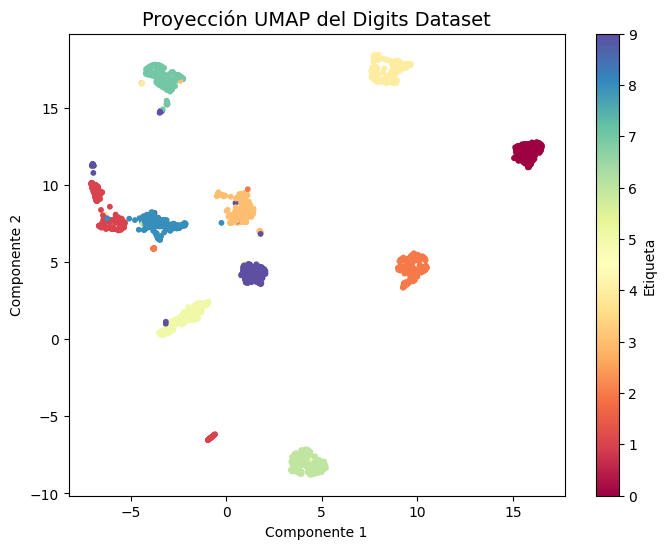

In [ ]:
# Instalación (si es necesario)
# !pip install umap-learn

import umap
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Cargar el dataset de dígitos
data, labels = load_digits(return_X_y=True)

# Aplicar UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(data)

# Visualizar
plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=10)
plt.colorbar(label='Etiqueta')
plt.title('Proyección UMAP del Digits Dataset', fontsize=14)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()


# Comparación con otros métodos de reducción de dimensionalidad

| Método  | Lineal | Preserva estructura local | Preserva estructura global | Velocidad | Visualización |
|---------|--------|----------------------------|-----------------------------|-----------|----------------|
| PCA     | Sí     | No                         | Parcial                     | Alta      | Limitada       |
| t-SNE   | No     | Sí                         | No                          | Media     | Muy buena      |
| UMAP    | No     | Sí                         | Sí                          | Alta      | Excelente      |


# ¿A qué tipo de datos se puede aplicar UMAP?

UMAP es muy versátil y puede aplicarse a una amplia variedad de tipos de datos, siempre que puedas representarlos como vectores numéricos. Aquí tienes los principales tipos:


## 📊 Datos Numéricos Tabulares
Ejemplo: Datos financieros, médicos, sensores, etc.

Aplicación: Reducción de dimensionalidad antes de clustering o visualización.


## 🔤 Datos de Texto
Ejemplo: Documentos, artículos, mensajes, etc.

Requisito: Primero debes convertir el texto en vectores, usando técnicas como:

TF-IDF

Word2Vec, GloVe

**Embeddings** de modelos como BERT

Aplicación: Agrupamiento de temas, detección de similitud semántica, análisis exploratorio.


## 🖼️ Imágenes
Ejemplo: Fotografías, dígitos manuscritos (como el dataset MNIST), imágenes médicas.

Requisito: Convertir cada imagen a un vector, por ejemplo:

Usar los pixeles directamente (si son pequeñas)

Extraer características con redes convolucionales (CNN)

Aplicación: Visualización de similitudes, segmentación por contenido visual.

## 🧬 Datos Biológicos o Genómicos
Ejemplo: Expresiones génicas, secuencias de ADN.

Aplicación: Análisis de poblaciones celulares, identificación de subtipos.

## 🎛️ Datos de Señales o Series Temporales
Ejemplo: Señales de EEG, audio, sensores IoT.

Requisito: Convertir a vectores representativos (por ejemplo, con ventanas deslizantes o extracción de características).

🎮 Datos de Juegos, Logs o Reglas
Ejemplo: Jugadas de ajedrez, registros de interacción de usuario.

Aplicación: Análisis de patrones, agrupamiento de estrategias.

## 📌 Nota:
UMAP no puede aplicarse directamente a datos categóricos (como "rojo", "verde", "azul") sin convertirlos a forma numérica. Una estrategia común es usar codificaciones como:

One-hot encoding

**Embeddings aprendidos**



A continuación te muestro cómo aplicar UMAP a datos categóricos, usando el conocido dataset "Mushroom" (hongos), que contiene características categóricas de diferentes especies de hongos, clasificadas como comestibles o venenosas.

Este ejemplo incluye:

Carga del dataset

Codificación de variables categóricas (One-hot encoding)

Aplicación de UMAP

Visualización en 2D

# 📦 Ejemplo en Python con Datos Categóricos: Dataset de Hongos

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


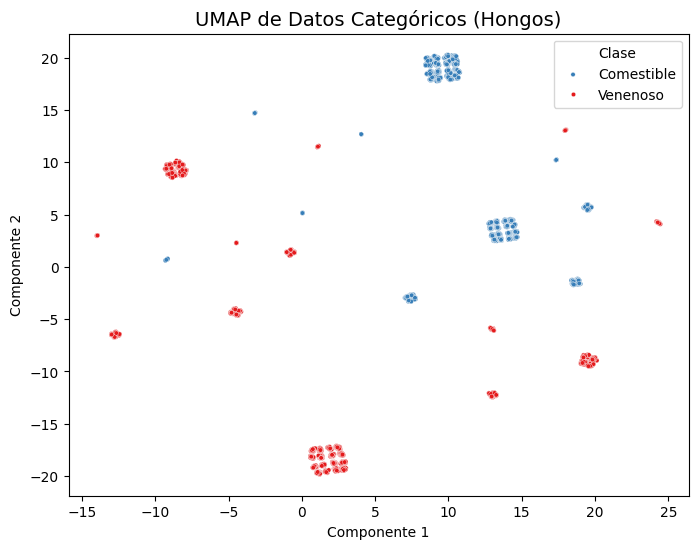

In [ ]:
# Instalar si es necesario
# !pip install pandas seaborn umap-learn

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap

# Cargar el dataset desde UCI (o usar seaborn para otras opciones)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
columns = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat'
]

data = pd.read_csv(url, header=None, names=columns)

# Codificación One-Hot para convertir datos categóricos en numéricos
X = pd.get_dummies(data.drop('class', axis=1))

# Etiquetas: comestible (e) o venenoso (p)
y = data['class'].map({'e': 0, 'p': 1})

# Reducir a 2 dimensiones con UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

# Visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=y, palette='Set1', s=10)
plt.title('UMAP de Datos Categóricos (Hongos)', fontsize=14)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Clase', labels=['Comestible', 'Venenoso'])
plt.show()


🧠 ¿Qué aprendemos de este ejemplo?
UMAP puede manejar datos categóricos si se transforman primero con one-hot encoding.

Es posible visualizar la separación natural entre clases (comestibles vs. venenosos).

Esto puede ayudar a detectar patrones o clusters en datos categóricos complejos.



🔹 Diferencias clave con t-SNE

| Aspecto                    | t-SNE 🌀                                              | UMAP 🔺                                         |
| -------------------------- | ----------------------------------------------------- | ----------------------------------------------- |
| Modelo matemático          | Probabilístico (distribuciones Gaussiana + Student-t) | Topológico (grafos y simplicial sets)           |
| Escalabilidad              | Lento en datasets grandes                             | Mucho más rápido, incluso en millones de puntos |
| Preserva estructura global | Pobre                                                 | Mejor                                           |
| Parámetros clave           | perplexity                                            | n\_neighbors, min\_dist                         |
| Uso típico                 | Visualización de clusters                             | Visualización + preprocesamiento                |
